In [84]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt


In [85]:
# ============================================================
# Switches
# ============================================================

NONLINEAR_ON = True
RAMAN_ON = True

SAVE_PROFILES = True
number_diagnostic = 100
profile_save_every = 5 * number_diagnostic

target_points_r = 50
target_points_t = 50

max_Nr = 4096
max_Nt = 4096

remesh_check_every = 50

In [86]:
# ============================================================
# Constants
# ============================================================

elem_charge = 1.602176634e-19
light_speed = 299792458
electron_mass = 9.109383713928e-31
eps0 = 8.854187818814e-12
kB = 1.380649e-23
reduced_planck = 1.054571817e-34

wavelength = 775e-9
wavenumber = 2 * np.pi / wavelength
omega = light_speed * wavenumber

ddot_wavenumber = 2.0 * (1e-15)**2 * (1e-2)**(-1)

waist0 = 0.7e-3
tp0 = 85e-15
nb = 1.0
n2 = 5.57e-23

Pcr = 1 / (2 * np.pi) * wavelength**2 / (nb * n2)

K = 7
beta = 6.5e-104
tau = 3.5e-13
Eg = 11 * elem_charge

a0_recomb = 5e-13

sigma = (
    wavenumber * elem_charge**2 * tau
    / (omega * electron_mass * eps0)
    / (1 + omega**2 * tau**2)
)

pressure = 101_325
temperature = 25 + 273.15
rho_neutral = 2 * pressure / (kB * temperature)

In [87]:
# ============================================================
# Initial mesh
# ============================================================

rmax = 10 * waist0
Nr = 1000

tmin = -5 * tp0
tmax = 5 * tp0
Nt = 1000

zmax = 4.0


In [88]:
# ============================================================
# Raman response
# ============================================================

def next_power_of_two(n):
    return 1 << (int(n) - 1).bit_length()


def make_raman_kernel_gpu(Nt_tot, DeltaT):
    """
    R(t) = theta(t) Omega^2 exp(-Gamma t/2) sin(Lambda t)/Lambda

    Omega = 20.6 THz
    Gamma = 26 THz

    Converted to rad/s.
    """

    Omega_R = 2 * np.pi * 20.6e12
    Gamma_R = 2 * np.pi * 26.0e12
    Lambda_R = np.sqrt(Omega_R**2 - Gamma_R**2 / 4)

    delay = cp.arange(Nt_tot, dtype=cp.float64) * DeltaT

    R = (
        Omega_R**2
        * cp.exp(-Gamma_R * delay / 2)
        * cp.sin(Lambda_R * delay)
        / Lambda_R
    )

    R[0] = 0.0

    norm = cp.sum(R) * DeltaT
    R = R / norm

    return cp.ascontiguousarray(R)


def raman_convolution_gpu(I, R_kernel, DeltaT):
    """
    Causal convolution:

        I_R[:, j] = sum_{m=0}^j R[j-m] I[:, m] DeltaT
    """

    Nr_tot, Nt_tot = I.shape
    nfft = next_power_of_two(2 * Nt_tot - 1)

    I_fft = cp.fft.rfft(I, n=nfft, axis=1)
    R_fft = cp.fft.rfft(R_kernel, n=nfft)

    conv_full = cp.fft.irfft(I_fft * R_fft[None, :], n=nfft, axis=1)

    I_raman = conv_full[:, :Nt_tot] * DeltaT

    return cp.ascontiguousarray(I_raman)

In [89]:
# ============================================================
# Fused RHS kernel
# ============================================================

rhs_kernel = cp.RawKernel(r'''
#include <cuComplex.h>

extern "C" __global__
void build_rhs(
    const cuDoubleComplex* E,
    const cuDoubleComplex* nonlinear,
    const cuDoubleComplex* lower,
    const cuDoubleComplex* main,
    const cuDoubleComplex* upper,
    cuDoubleComplex* RHS,
    int M,
    int N,
    double DeltaZ,
    int include_nonlinear
)
{
    int idx = blockDim.x * blockIdx.x + threadIdx.x;
    int total = M * N;

    if (idx >= total) return;

    int i = idx / N;
    int j = idx - i * N;

    cuDoubleComplex val = cuCmul(E[idx], main[j]);

    if (j > 0) {
        val = cuCadd(val, cuCmul(E[i * N + j - 1], upper[j - 1]));
    }

    if (j < N - 1) {
        val = cuCadd(val, cuCmul(E[i * N + j + 1], lower[j]));
    }

    if (include_nonlinear) {
        cuDoubleComplex nl = nonlinear[idx];

        val = cuCadd(
            val,
            make_cuDoubleComplex(
                DeltaZ * cuCreal(nl),
                DeltaZ * cuCimag(nl)
            )
        );
    }

    RHS[idx] = val;
}
''', "build_rhs")


def build_rhs_gpu(E, nonlinear, lower, main, upper, DeltaZ, include_nonlinear=True):
    M, N = E.shape
    RHS = cp.empty_like(E)

    threads = 256
    blocks = (M * N + threads - 1) // threads

    rhs_kernel(
        (blocks,),
        (threads,),
        (
            E,
            nonlinear,
            lower,
            main,
            upper,
            RHS,
            np.int32(M),
            np.int32(N),
            float(DeltaZ),
            np.int32(1 if include_nonlinear else 0),
        ),
    )

    return RHS

In [90]:
# ============================================================
# Thomas fallback solver
# ============================================================

thomas_kernel = cp.RawKernel(r'''
#include <cuComplex.h>

extern "C" __global__
void thomas_batch(
    const cuDoubleComplex* lower,
    const cuDoubleComplex* main,
    const cuDoubleComplex* upper,
    const cuDoubleComplex* RHS,
    cuDoubleComplex* X,
    cuDoubleComplex* cprime,
    cuDoubleComplex* dprime,
    int N,
    int M
)
{
    int col = blockDim.x * blockIdx.x + threadIdx.x;
    if (col >= M) return;

    int offset = col * N;

    cuDoubleComplex denom = main[0];

    cprime[offset] = cuCdiv(upper[0], denom);
    dprime[offset] = cuCdiv(RHS[col], denom);

    for (int i = 1; i < N; i++) {
        cuDoubleComplex a = lower[i - 1];
        cuDoubleComplex b = main[i];

        denom = cuCsub(b, cuCmul(a, cprime[offset + i - 1]));

        if (i < N - 1) {
            cprime[offset + i] = cuCdiv(upper[i], denom);
        }

        cuDoubleComplex rhs = RHS[i * M + col];

        dprime[offset + i] = cuCdiv(
            cuCsub(rhs, cuCmul(a, dprime[offset + i - 1])),
            denom
        );
    }

    X[(N - 1) * M + col] = dprime[offset + N - 1];

    for (int i = N - 2; i >= 0; i--) {
        X[i * M + col] = cuCsub(
            dprime[offset + i],
            cuCmul(cprime[offset + i], X[(i + 1) * M + col])
        );
    }
}
''', "thomas_batch")


def solve_tridiag_batch_thomas_gpu(lower, main, upper, RHS):
    RHS = cp.ascontiguousarray(RHS)

    N, M = RHS.shape
    X = cp.empty_like(RHS)

    cprime = cp.empty((M, N), dtype=cp.complex128)
    dprime = cp.empty((M, N), dtype=cp.complex128)

    threads = 128
    blocks = (M + threads - 1) // threads

    thomas_kernel(
        (blocks,),
        (threads,),
        (
            lower,
            main,
            upper,
            RHS,
            X,
            cprime,
            dprime,
            np.int32(N),
            np.int32(M),
        ),
    )

    return X

In [91]:
# ============================================================
# PCR solver
# ============================================================

pcr_kernel = cp.RawKernel(r'''
#include <cuComplex.h>

extern "C" __global__
void pcr_batch(
    const cuDoubleComplex* lower,
    const cuDoubleComplex* main,
    const cuDoubleComplex* upper,
    const cuDoubleComplex* RHS,
    cuDoubleComplex* X,
    int N,
    int M
)
{
    int col = blockIdx.x;
    int i = threadIdx.x;

    extern __shared__ cuDoubleComplex shared[];

    cuDoubleComplex* a = shared;
    cuDoubleComplex* b = shared + N;
    cuDoubleComplex* c = shared + 2 * N;
    cuDoubleComplex* d = shared + 3 * N;

    if (i < N) {
        a[i] = (i == 0)     ? make_cuDoubleComplex(0.0, 0.0) : lower[i - 1];
        b[i] = main[i];
        c[i] = (i == N - 1) ? make_cuDoubleComplex(0.0, 0.0) : upper[i];
        d[i] = RHS[i * M + col];
    }

    __syncthreads();

    for (int stride = 1; stride < N; stride *= 2) {

        cuDoubleComplex ai = make_cuDoubleComplex(0.0, 0.0);
        cuDoubleComplex bi = make_cuDoubleComplex(0.0, 0.0);
        cuDoubleComplex ci = make_cuDoubleComplex(0.0, 0.0);
        cuDoubleComplex di = make_cuDoubleComplex(0.0, 0.0);

        if (i < N) {
            ai = a[i];
            bi = b[i];
            ci = c[i];
            di = d[i];

            cuDoubleComplex alpha = make_cuDoubleComplex(0.0, 0.0);
            cuDoubleComplex beta_c = make_cuDoubleComplex(0.0, 0.0);

            if (i - stride >= 0) {
                alpha = cuCdiv(
                    make_cuDoubleComplex(-cuCreal(ai), -cuCimag(ai)),
                    b[i - stride]
                );
            }

            if (i + stride < N) {
                beta_c = cuCdiv(
                    make_cuDoubleComplex(-cuCreal(ci), -cuCimag(ci)),
                    b[i + stride]
                );
            }

            cuDoubleComplex new_a = make_cuDoubleComplex(0.0, 0.0);
            cuDoubleComplex new_b = bi;
            cuDoubleComplex new_c = make_cuDoubleComplex(0.0, 0.0);
            cuDoubleComplex new_d = di;

            if (i - stride >= 0) {
                new_b = cuCadd(new_b, cuCmul(alpha, c[i - stride]));
                new_d = cuCadd(new_d, cuCmul(alpha, d[i - stride]));
                new_a = cuCmul(alpha, a[i - stride]);
            }

            if (i + stride < N) {
                new_b = cuCadd(new_b, cuCmul(beta_c, a[i + stride]));
                new_d = cuCadd(new_d, cuCmul(beta_c, d[i + stride]));
                new_c = cuCmul(beta_c, c[i + stride]);
            }

            ai = new_a;
            bi = new_b;
            ci = new_c;
            di = new_d;
        }

        __syncthreads();

        if (i < N) {
            a[i] = ai;
            b[i] = bi;
            c[i] = ci;
            d[i] = di;
        }

        __syncthreads();
    }

    if (i < N) {
        X[i * M + col] = cuCdiv(d[i], b[i]);
    }
}
''', "pcr_batch")


def solve_tridiag_batch_gpu(lower, main, upper, RHS):
    RHS = cp.ascontiguousarray(RHS)

    N, M = RHS.shape

    threads = next_power_of_two(N)
    shared_mem = 4 * N * 16

    if threads > 1024 or shared_mem > 48 * 1024:
        return solve_tridiag_batch_thomas_gpu(lower, main, upper, RHS)

    X = cp.empty_like(RHS)

    pcr_kernel(
        (M,),
        (threads,),
        (
            lower,
            main,
            upper,
            RHS,
            X,
            np.int32(N),
            np.int32(M),
        ),
        shared_mem=shared_mem,
    )

    return X

In [92]:
# ============================================================
# Base physics kernel: I, I^6, rho, length scales
# ============================================================

base_physics_kernel = cp.RawKernel(r'''
#include <cuComplex.h>

extern "C" __global__
void base_physics(
    const cuDoubleComplex* E,
    double* I,
    double* Ipow,
    double* rho,
    double* row_l_mpa,
    double* row_l_kerr,
    double* row_l_plasma,
    int Nr_tot,
    int Nt_tot,
    double beta,
    double K,
    double hbar,
    double omega,
    double rho_neutral,
    double wavenumber,
    double n2,
    double sigma,
    double tau,
    double DeltaT,
    double nb,
    double Eg
)
{
    int r = blockDim.x * blockIdx.x + threadIdx.x;
    if (r >= Nr_tot) return;

    double min_l_mpa = 1.0e300;
    double min_l_kerr = 1.0e300;
    double min_l_plasma = 1.0e300;

    double plasma_abs = sigma * sqrt(1.0 + omega * omega * tau * tau);

    for (int t = 0; t < Nt_tot; t++) {
        int idx = r * Nt_tot + t;

        cuDoubleComplex e = E[idx];

        double er = cuCreal(e);
        double ei = cuCimag(e);

        double Ii = er * er + ei * ei;
        I[idx] = Ii;

        double I2 = Ii * Ii;
        double I6 = I2 * I2 * I2;
        Ipow[idx] = I6;

        if (Ii > 0.0) {
            double lk = 1.0 / (wavenumber * n2 * Ii);
            if (lk < min_l_kerr) min_l_kerr = lk;
        }

        if (I6 > 0.0) {
            double lm = 2.0 / (beta * I6);
            if (lm < min_l_mpa) min_l_mpa = lm;
        }
    }

    double u = rho_neutral;
    rho[r * Nt_tot] = 0.0;

    double a_prefactor = sigma / (nb * nb * Eg);
    double b_prefactor = beta / (K * hbar * omega * rho_neutral);

    for (int t = 0; t < Nt_tot - 1; t++) {
        int idx0 = r * Nt_tot + t;
        int idx1 = r * Nt_tot + t + 1;

        double I0 = I[idx0];
        double I1 = I[idx1];

        double a_left = a_prefactor * I0;
        double a_right = a_prefactor * I1;

        double b_left = b_prefactor * Ipow[idx0] * I0;
        double b_right = b_prefactor * Ipow[idx1] * I1;

        double a_mid = 0.5 * (a_left + a_right);
        double b_mid = 0.5 * (b_left + b_right);

        double gamma = b_mid - a_mid;
        double source = -a_mid * rho_neutral;

        double x = -DeltaT * gamma;
        double g = exp(x);

        double h;

        if (fabs(gamma) > 1.0e-30) {
            h = source * (1.0 - g) / gamma;
        } else {
            h = source * DeltaT;
        }

        u = g * u + h;

        double rhoi = rho_neutral - u;

        if (rhoi < 0.0) rhoi = 0.0;
        if (rhoi > rho_neutral) rhoi = rho_neutral;

        rho[idx1] = rhoi;
        u = rho_neutral - rhoi;

        if (rhoi > 0.0) {
            double lp = 2.0 / (plasma_abs * rhoi);
            if (lp < min_l_plasma) min_l_plasma = lp;
        }
    }

    row_l_mpa[r] = min_l_mpa;
    row_l_kerr[r] = min_l_kerr;
    row_l_plasma[r] = min_l_plasma;
}
''', "base_physics")


def compute_base_physics_gpu(E, DeltaT):
    Nr_tot, Nt_tot = E.shape

    I = cp.empty((Nr_tot, Nt_tot), dtype=cp.float64)
    I_pow = cp.empty((Nr_tot, Nt_tot), dtype=cp.float64)
    rho = cp.empty((Nr_tot, Nt_tot), dtype=cp.float64)

    row_l_mpa = cp.empty(Nr_tot, dtype=cp.float64)
    row_l_kerr = cp.empty(Nr_tot, dtype=cp.float64)
    row_l_plasma = cp.empty(Nr_tot, dtype=cp.float64)

    threads = 128
    blocks = (Nr_tot + threads - 1) // threads

    base_physics_kernel(
        (blocks,),
        (threads,),
        (
            E,
            I,
            I_pow,
            rho,
            row_l_mpa,
            row_l_kerr,
            row_l_plasma,
            np.int32(Nr_tot),
            np.int32(Nt_tot),
            float(beta),
            float(K),
            float(reduced_planck),
            float(omega),
            float(rho_neutral),
            float(wavenumber),
            float(n2),
            float(sigma),
            float(tau),
            float(DeltaT),
            float(nb),
            float(Eg),
        ),
    )

    lengths_gpu = cp.array([
        cp.min(row_l_mpa),
        cp.min(row_l_kerr),
        cp.min(row_l_plasma),
    ])

    lengths_cpu = cp.asnumpy(lengths_gpu)

    l_MPA = float(lengths_cpu[0])
    l_Kerr = float(lengths_cpu[1])
    l_plasma = float(lengths_cpu[2])

    return I, I_pow, rho, l_MPA, l_Kerr, l_plasma

In [93]:
# ============================================================
# Nonlinear kernel with Raman-Kerr
# ============================================================

nonlinear_kernel = cp.RawKernel(r'''
#include <cuComplex.h>

extern "C" __global__
void build_nonlinear(
    const cuDoubleComplex* E,
    const double* I,
    const double* Ipow,
    const double* rho,
    const double* Iraman,
    cuDoubleComplex* current_nonlinear,
    int total,
    int nonlinear_on,
    int raman_on,
    double beta,
    double wavenumber,
    double n2,
    double sigma,
    double omega,
    double tau
)
{
    int idx = blockDim.x * blockIdx.x + threadIdx.x;
    if (idx >= total) return;

    if (nonlinear_on == 0) {
        current_nonlinear[idx] = make_cuDoubleComplex(0.0, 0.0);
        return;
    }

    cuDoubleComplex e = E[idx];

    double Ii = I[idx];
    double I6 = Ipow[idx];
    double rhoi = rho[idx];

    double Ieff;

    if (raman_on == 1) {
        Ieff = 0.5 * Ii + 0.5 * Iraman[idx];
    } else {
        Ieff = Ii;
    }

    double er = cuCreal(e);
    double ei = cuCimag(e);

    cuDoubleComplex term1 = make_cuDoubleComplex(
        -0.5 * beta * I6 * er,
        -0.5 * beta * I6 * ei
    );

    cuDoubleComplex term2_factor = make_cuDoubleComplex(
        0.0,
        wavenumber * n2 * Ieff
    );

    cuDoubleComplex term2 = cuCmul(term2_factor, e);

    cuDoubleComplex plasma_factor = make_cuDoubleComplex(
        -0.5 * sigma * rhoi,
        -0.5 * sigma * omega * tau * rhoi
    );

    cuDoubleComplex term3 = cuCmul(plasma_factor, e);

    current_nonlinear[idx] = cuCadd(cuCadd(term1, term2), term3);
}
''', "build_nonlinear")


def build_nonlinear_gpu(E, I, I_pow, rho, I_raman, nonlinear_on=True, raman_on=True):
    current_nonlinear = cp.empty_like(E)

    total = E.size
    threads = 256
    blocks = (total + threads - 1) // threads

    nonlinear_kernel(
        (blocks,),
        (threads,),
        (
            E,
            I,
            I_pow,
            rho,
            I_raman,
            current_nonlinear,
            np.int32(total),
            np.int32(1 if nonlinear_on else 0),
            np.int32(1 if raman_on else 0),
            float(beta),
            float(wavenumber),
            float(n2),
            float(sigma),
            float(omega),
            float(tau),
        ),
    )

    return current_nonlinear


def update_physics_gpu(E, DeltaT, R_kernel=None, nonlinear_on=True, raman_on=True):
    I, I_pow, rho, l_MPA, l_Kerr, l_plasma = compute_base_physics_gpu(E, DeltaT)

    if nonlinear_on and raman_on:
        I_raman = raman_convolution_gpu(I, R_kernel, DeltaT)
    else:
        I_raman = cp.zeros_like(I)

    current_nonlinear = build_nonlinear_gpu(
        E,
        I,
        I_pow,
        rho,
        I_raman,
        nonlinear_on=nonlinear_on,
        raman_on=raman_on,
    )

    return I, I_pow, rho, current_nonlinear, l_MPA, l_Kerr, l_plasma

In [94]:
# ============================================================
# Remeshing kernel
# ============================================================

remesh_kernel = cp.RawKernel(r'''
#include <cuComplex.h>

extern "C" __global__
void remesh_complex_uniform(
    const cuDoubleComplex* E_old,
    cuDoubleComplex* E_new,
    int Nr_old_tot,
    int Nt_old_tot,
    int Nr_new_tot,
    int Nt_new_tot,
    double DeltaR_old,
    double tmin_old,
    double DeltaT_old,
    double DeltaR_new,
    double tmin_new,
    double DeltaT_new
)
{
    int idx_new = blockDim.x * blockIdx.x + threadIdx.x;
    int total = Nr_new_tot * Nt_new_tot;

    if (idx_new >= total) return;

    int i_new = idx_new / Nt_new_tot;
    int j_new = idx_new - i_new * Nt_new_tot;

    double r = i_new * DeltaR_new;
    double t = tmin_new + j_new * DeltaT_new;

    double x = r / DeltaR_old;
    double y = (t - tmin_old) / DeltaT_old;

    int i0 = (int)floor(x);
    int j0 = (int)floor(y);

    if (i0 < 0 || i0 >= Nr_old_tot - 1 || j0 < 0 || j0 >= Nt_old_tot - 1) {
        E_new[idx_new] = make_cuDoubleComplex(0.0, 0.0);
        return;
    }

    double ar = x - i0;
    double at = y - j0;

    int idx00 = i0 * Nt_old_tot + j0;
    int idx10 = (i0 + 1) * Nt_old_tot + j0;
    int idx01 = i0 * Nt_old_tot + (j0 + 1);
    int idx11 = (i0 + 1) * Nt_old_tot + (j0 + 1);

    cuDoubleComplex E00 = E_old[idx00];
    cuDoubleComplex E10 = E_old[idx10];
    cuDoubleComplex E01 = E_old[idx01];
    cuDoubleComplex E11 = E_old[idx11];

    double w00 = (1.0 - ar) * (1.0 - at);
    double w10 = ar * (1.0 - at);
    double w01 = (1.0 - ar) * at;
    double w11 = ar * at;

    double real_part =
        w00 * cuCreal(E00) +
        w10 * cuCreal(E10) +
        w01 * cuCreal(E01) +
        w11 * cuCreal(E11);

    double imag_part =
        w00 * cuCimag(E00) +
        w10 * cuCimag(E10) +
        w01 * cuCimag(E01) +
        w11 * cuCimag(E11);

    E_new[idx_new] = make_cuDoubleComplex(real_part, imag_part);
}
''', "remesh_complex_uniform")

In [95]:
# ============================================================
# Grid and operators
# ============================================================

def make_grid(Nr, Nt, rmax, tmin, tmax):
    DeltaR = rmax / (Nr + 1)
    DeltaT = (tmax - tmin) / (Nt + 1)

    r_vector = cp.linspace(0.0, rmax, Nr + 2)
    t_vector = cp.linspace(tmin, tmax, Nt + 2)

    r_matrix, t_matrix = cp.meshgrid(r_vector, t_vector, indexing="ij")

    l_rad = 4 * wavenumber * DeltaR**2
    l_GVD = 4 * DeltaT**2 / abs(ddot_wavenumber)

    return DeltaR, DeltaT, r_vector, t_vector, r_matrix, t_matrix, l_rad, l_GVD


def transpose_tridiag(lower, main, upper):
    return upper.copy(), main.copy(), lower.copy()


def generate_L_plus_delta_diags(DeltaZ, Nr, DeltaR):
    delta = DeltaZ / (4 * wavenumber * DeltaR**2)

    main = cp.array(
        [1 - 4j * delta]
        + [1 - 2j * delta for _ in range(1, Nr + 1)]
        + [0],
        dtype=cp.complex128,
    )

    upper = cp.array(
        [4j * delta]
        + [1j * delta * (1 + 0.5 / i) for i in range(1, Nr + 1)],
        dtype=cp.complex128,
    )

    lower = cp.array(
        [1j * delta * (1 - 0.5 / i) for i in range(1, Nr + 1)]
        + [0],
        dtype=cp.complex128,
    )

    return lower, main, upper


def generate_L_minus_delta_diags(DeltaZ, Nr, DeltaR):
    delta = DeltaZ / (4 * wavenumber * DeltaR**2)

    main = cp.array(
        [1 + 4j * delta]
        + [1 + 2j * delta for _ in range(1, Nr + 1)]
        + [1],
        dtype=cp.complex128,
    )

    upper = cp.array(
        [-4j * delta]
        + [-1j * delta * (1 + 0.5 / i) for i in range(1, Nr + 1)],
        dtype=cp.complex128,
    )

    lower = cp.array(
        [-1j * delta * (1 - 0.5 / i) for i in range(1, Nr + 1)]
        + [0],
        dtype=cp.complex128,
    )

    return lower, main, upper


def generate_L_plus_d_diags(DeltaZ, Nt, DeltaT):
    d = -ddot_wavenumber * DeltaZ / (4 * DeltaT**2)

    main = cp.array(
        [1 - 2j * d for _ in range(0, Nt + 1)] + [0],
        dtype=cp.complex128,
    )

    upper = cp.array(
        [1j * d for _ in range(0, Nt)] + [0],
        dtype=cp.complex128,
    )

    lower = cp.array(
        [2j * d] + [1j * d for _ in range(2, Nt + 2)],
        dtype=cp.complex128,
    )

    return lower, main, upper


def generate_L_minus_d_diags(DeltaZ, Nt, DeltaT):
    d = -ddot_wavenumber * DeltaZ / (4 * DeltaT**2)

    main = cp.array(
        [1 + 2j * d for _ in range(0, Nt + 1)] + [1],
        dtype=cp.complex128,
    )

    upper = cp.array(
        [-1j * d for _ in range(0, Nt)] + [0],
        dtype=cp.complex128,
    )

    lower = cp.array(
        [-2j * d] + [-1j * d for _ in range(2, Nt + 2)],
        dtype=cp.complex128,
    )

    return lower, main, upper


def regenerate_all_diagonals(DeltaZ, Nr, Nt, DeltaR, DeltaT):
    L_plus_d = generate_L_plus_d_diags(DeltaZ, Nt, DeltaT)
    L_minus_d = generate_L_minus_d_diags(DeltaZ, Nt, DeltaT)

    L_plus_delta = generate_L_plus_delta_diags(DeltaZ, Nr, DeltaR)
    L_minus_delta = generate_L_minus_delta_diags(DeltaZ, Nr, DeltaR)

    L_plus_delta_T = transpose_tridiag(*L_plus_delta)
    L_minus_d_T = transpose_tridiag(*L_minus_d)

    return (
        L_plus_d,
        L_minus_d,
        L_plus_delta,
        L_minus_delta,
        L_plus_delta_T,
        L_minus_d_T,
    )

In [96]:
# ============================================================
# Remeshing
# ============================================================

def remesh_E_gpu(
    E_old,
    Nr_old,
    Nt_old,
    rmax_old,
    tmin_old,
    tmax_old,
    Nr_new,
    Nt_new,
    rmax_new,
    tmin_new,
    tmax_new,
):
    DeltaR_old = rmax_old / (Nr_old + 1)
    DeltaT_old = (tmax_old - tmin_old) / (Nt_old + 1)

    DeltaR_new = rmax_new / (Nr_new + 1)
    DeltaT_new = (tmax_new - tmin_new) / (Nt_new + 1)

    E_old = cp.ascontiguousarray(E_old)
    E_new = cp.empty((Nr_new + 2, Nt_new + 2), dtype=cp.complex128)

    total = (Nr_new + 2) * (Nt_new + 2)
    threads = 256
    blocks = (total + threads - 1) // threads

    remesh_kernel(
        (blocks,),
        (threads,),
        (
            E_old,
            E_new,
            np.int32(Nr_old + 2),
            np.int32(Nt_old + 2),
            np.int32(Nr_new + 2),
            np.int32(Nt_new + 2),
            float(DeltaR_old),
            float(tmin_old),
            float(DeltaT_old),
            float(DeltaR_new),
            float(tmin_new),
            float(DeltaT_new),
        ),
    )

    return cp.ascontiguousarray(E_new)


def compute_widths_gpu(I, r_matrix, t_matrix, DeltaR, DeltaT):
    weight = I * r_matrix

    norm = cp.sum(weight) * DeltaR * DeltaT

    r2_mean = cp.sum(I * r_matrix**3) * DeltaR * DeltaT / norm
    t2_mean = cp.sum(weight * t_matrix**2) * DeltaR * DeltaT / norm

    r_rms = cp.sqrt(r2_mean)
    t_rms = cp.sqrt(t2_mean)

    w_eff = cp.sqrt(2.0) * r_rms
    tp_eff = 2.0 * t_rms

    return float(w_eff.get()), float(tp_eff.get())


def maybe_remesh(E, I, Nr, Nt, rmax, tmin, tmax, DeltaR, DeltaT, r_matrix, t_matrix):
    w_eff, tp_eff = compute_widths_gpu(I, r_matrix, t_matrix, DeltaR, DeltaT)

    wanted_DeltaR = w_eff / target_points_r
    wanted_DeltaT = tp_eff / target_points_t

    need_r = DeltaR > wanted_DeltaR
    need_t = DeltaT > wanted_DeltaT

    if not need_r and not need_t:
        return False, E, Nr, Nt, rmax, tmin, tmax

    Nr_new = Nr
    Nt_new = Nt

    if need_r:
        Nr_target = int(np.ceil(rmax / wanted_DeltaR)) - 1
        Nr_new = max(Nr_target, int(1.5 * Nr))
        Nr_new = min(Nr_new, max_Nr)

    if need_t:
        width_t = tmax - tmin
        Nt_target = int(np.ceil(width_t / wanted_DeltaT)) - 1
        Nt_new = max(Nt_target, int(1.5 * Nt))
        Nt_new = min(Nt_new, max_Nt)

    if Nr_new == Nr and Nt_new == Nt:
        return False, E, Nr, Nt, rmax, tmin, tmax

    print(
        f"Remeshing: Nr {Nr} -> {Nr_new}, Nt {Nt} -> {Nt_new}, "
        f"w_eff/DeltaR = {w_eff / DeltaR:.1f}, "
        f"tp_eff/DeltaT = {tp_eff / DeltaT:.1f}"
    )

    E_new = remesh_E_gpu(
        E,
        Nr,
        Nt,
        rmax,
        tmin,
        tmax,
        Nr_new,
        Nt_new,
        rmax,
        tmin,
        tmax,
    )

    return True, E_new, Nr_new, Nt_new, rmax, tmin, tmax


def exact_I_central_linear(z_array, I0):
    z_array = np.asarray(z_array)

    zR = 0.5 * wavenumber * waist0**2
    s = 2 * ddot_wavenumber * z_array / tp0**2

    return I0 / (1 + (z_array / zR)**2) / np.sqrt(1 + s**2)

In [97]:
# ============================================================
# Initial condition
# ============================================================

DeltaR, DeltaT, r_vector, t_vector, r_matrix, t_matrix, l_rad, l_GVD = make_grid(
    Nr,
    Nt,
    rmax,
    tmin,
    tmax,
)

R_kernel = make_raman_kernel_gpu(Nt + 2, DeltaT)

Pin = 6.5 * Pcr
amp = np.sqrt(2 * Pin / np.pi / waist0**2)

E = amp * cp.exp(
    -r_matrix**2 / waist0**2
    - t_matrix**2 / tp0**2
).astype(cp.complex128)

E = cp.ascontiguousarray(E)

I, I_pow, rho, current_nonlinear, l_MPA, l_Kerr, l_plasma = update_physics_gpu(
    E,
    DeltaT,
    R_kernel=R_kernel,
    nonlinear_on=NONLINEAR_ON,
    raman_on=RAMAN_ON,
)

past_nonlinear = current_nonlinear.copy()

z_vector = [0.0]
z_diagnostic = [0.0]

I_central = [float(I[0, (Nt + 2) // 2].get())]

I_profile = []
I_profile_z = []

if SAVE_PROFILES:
    I_profile.append(cp.asnumpy(I))
    I_profile_z.append(0.0)

DeltaZ = 0.05 * min(l_Kerr, l_MPA, l_plasma, l_rad, l_GVD)

(
    L_plus_d,
    L_minus_d,
    L_plus_delta,
    L_minus_delta,
    L_plus_delta_T,
    L_minus_d_T,
) = regenerate_all_diagonals(DeltaZ, Nr, Nt, DeltaR, DeltaT)

In [98]:
# ============================================================
# Propagation loop
# ============================================================

index = 0
last_l_ref_for_remesh = min(l_Kerr, l_MPA, l_plasma, l_rad, l_GVD)

while True:

    l_ref = min(l_Kerr, l_MPA, l_plasma, l_rad, l_GVD)

    new_DeltaZ = 0.05 * l_ref

    if not 0.5 * new_DeltaZ <= DeltaZ <= 2.0 * new_DeltaZ:
        DeltaZ = new_DeltaZ

        if z_vector[-1] + DeltaZ > zmax:
            DeltaZ = zmax - z_vector[-1]

        (
            L_plus_d,
            L_minus_d,
            L_plus_delta,
            L_minus_delta,
            L_plus_delta_T,
            L_minus_d_T,
        ) = regenerate_all_diagonals(DeltaZ, Nr, Nt, DeltaR, DeltaT)

    if z_vector[-1] + DeltaZ > zmax:
        DeltaZ = zmax - z_vector[-1]

        (
            L_plus_d,
            L_minus_d,
            L_plus_delta,
            L_minus_delta,
            L_plus_delta_T,
            L_minus_d_T,
        ) = regenerate_all_diagonals(DeltaZ, Nr, Nt, DeltaR, DeltaT)

    if NONLINEAR_ON:
        nonlinear = 1.5 * current_nonlinear - 0.5 * past_nonlinear
    else:
        nonlinear = cp.empty_like(E)

    RHS = build_rhs_gpu(
        E,
        nonlinear,
        L_plus_d[0],
        L_plus_d[1],
        L_plus_d[2],
        DeltaZ,
        include_nonlinear=NONLINEAR_ON,
    )

    intermediary = solve_tridiag_batch_gpu(
        L_minus_delta[0],
        L_minus_delta[1],
        L_minus_delta[2],
        RHS,
    ).T

    intermediary = cp.ascontiguousarray(intermediary)

    dummy = cp.empty_like(intermediary)

    RHS = build_rhs_gpu(
        intermediary,
        dummy,
        L_plus_delta_T[0],
        L_plus_delta_T[1],
        L_plus_delta_T[2],
        0.0,
        include_nonlinear=False,
    )

    E = solve_tridiag_batch_gpu(
        L_minus_d_T[0],
        L_minus_d_T[1],
        L_minus_d_T[2],
        RHS,
    ).T

    E = cp.ascontiguousarray(E)

    past_nonlinear = current_nonlinear

    I, I_pow, rho, current_nonlinear, l_MPA, l_Kerr, l_plasma = update_physics_gpu(
        E,
        DeltaT,
        R_kernel=R_kernel,
        nonlinear_on=NONLINEAR_ON,
        raman_on=RAMAN_ON,
    )

    z_new = z_vector[-1] + DeltaZ
    z_vector.append(z_new)

    index += 1

    rapid_change = l_ref < 0.7 * last_l_ref_for_remesh
    scheduled_check = index % remesh_check_every == 0

    if scheduled_check or rapid_change:

        did_remesh, E, Nr, Nt, rmax, tmin, tmax = maybe_remesh(
            E,
            I,
            Nr,
            Nt,
            rmax,
            tmin,
            tmax,
            DeltaR,
            DeltaT,
            r_matrix,
            t_matrix,
        )

        last_l_ref_for_remesh = l_ref

        if did_remesh:

            DeltaR, DeltaT, r_vector, t_vector, r_matrix, t_matrix, l_rad, l_GVD = make_grid(
                Nr,
                Nt,
                rmax,
                tmin,
                tmax,
            )

            R_kernel = make_raman_kernel_gpu(Nt + 2, DeltaT)

            I, I_pow, rho, current_nonlinear, l_MPA, l_Kerr, l_plasma = update_physics_gpu(
                E,
                DeltaT,
                R_kernel=R_kernel,
                nonlinear_on=NONLINEAR_ON,
                raman_on=RAMAN_ON,
            )

            past_nonlinear = current_nonlinear.copy()

            DeltaZ = 0.05 * min(l_Kerr, l_MPA, l_plasma, l_rad, l_GVD)

            (
                L_plus_d,
                L_minus_d,
                L_plus_delta,
                L_minus_delta,
                L_plus_delta_T,
                L_minus_d_T,
            ) = regenerate_all_diagonals(DeltaZ, Nr, Nt, DeltaR, DeltaT)

    if index % number_diagnostic == 0:
        z_diagnostic.append(z_new)
        I_central.append(float(I[0, (Nt + 2) // 2].get()))

        if SAVE_PROFILES and index % profile_save_every == 0:
            I_profile.append(cp.asnumpy(I))
            I_profile_z.append(z_new)

        print(
            f"step = {index}, "
            f"z = {z_new:.6e} m, "
            f"DeltaZ = {DeltaZ:.3e} m, "
            f"Nr = {Nr}, Nt = {Nt}, "
            f"I_center = {I_central[-1]:.6e}, "
            f"I/I0 = {I_central[-1] / I_central[0]:.3e}, "
            f"l_ref = {l_ref:.3e}, "
            f"l_Kerr = {l_Kerr:.3e}, "
            f"l_MPA = {l_MPA:.3e}, "
            f"l_plasma = {l_plasma:.3e}, "
            f"l_rad = {l_rad:.3e}, "
            f"l_GVD = {l_GVD:.3e}"
        )

    if z_new >= zmax:
        break

step = 100, z = 7.929323e-03 m, DeltaZ = 7.929e-05 m, Nr = 1000, Nt = 1000, I_center = 1.449801e+16, I/I0 = 1.000e+00, l_ref = 1.586e-03, l_Kerr = 1.527e-01, l_MPA = 3.313e+06, l_plasma = 2.326e+06, l_rad = 1.586e-03, l_GVD = 1.442e-02
step = 200, z = 1.585865e-02 m, DeltaZ = 7.929e-05 m, Nr = 1000, Nt = 1000, I_center = 1.451430e+16, I/I0 = 1.002e+00, l_ref = 1.586e-03, l_Kerr = 1.526e-01, l_MPA = 3.291e+06, l_plasma = 2.309e+06, l_rad = 1.586e-03, l_GVD = 1.442e-02
step = 300, z = 2.378797e-02 m, DeltaZ = 7.929e-05 m, Nr = 1000, Nt = 1000, I_center = 1.454149e+16, I/I0 = 1.003e+00, l_ref = 1.586e-03, l_Kerr = 1.523e-01, l_MPA = 3.254e+06, l_plasma = 2.281e+06, l_rad = 1.586e-03, l_GVD = 1.442e-02
step = 400, z = 3.171729e-02 m, DeltaZ = 7.929e-05 m, Nr = 1000, Nt = 1000, I_center = 1.457974e+16, I/I0 = 1.006e+00, l_ref = 1.586e-03, l_Kerr = 1.519e-01, l_MPA = 3.203e+06, l_plasma = 2.242e+06, l_rad = 1.586e-03, l_GVD = 1.442e-02
step = 500, z = 3.964661e-02 m, DeltaZ = 7.929e-05 m, Nr

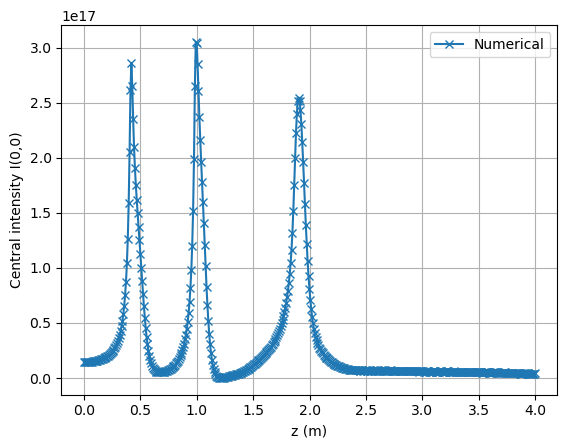

In [99]:
# ============================================================
# Plots
# ============================================================

plt.figure()
plt.plot(z_diagnostic, I_central, "x-", label="Numerical")
plt.xlabel("z (m)")
plt.ylabel("Central intensity I(0,0)")
plt.grid(True)
plt.legend()
plt.show()


if not NONLINEAR_ON:
    z_diag = np.array(z_diagnostic)
    I_num = np.array(I_central)

    I_exact = exact_I_central_linear(z_diag, I_num[0])
    rel_error = np.abs(I_num - I_exact) / I_exact

    print("Linear test:")
    print("max relative error =", np.max(rel_error))
    print("mean relative error =", np.mean(rel_error))
    print("final relative error =", rel_error[-1])

    plt.figure()
    plt.plot(z_diag, I_num, "x", label="Numerical")
    plt.plot(z_diag, I_exact, "-", label="Exact linear")
    plt.xlabel("z (m)")
    plt.ylabel("Central intensity I(0,0)")
    plt.title("Linear test: numerical vs exact")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure()
    plt.semilogy(z_diag, rel_error)
    plt.xlabel("z (m)")
    plt.ylabel("Relative error")
    plt.title("Linear test relative error")
    plt.grid(True)
    plt.show()